# Notebook 3 — Evaluation (nuScenes v1.0-trainval)

## Kaggle setup
- Attach NB1 output dataset and NB2 output dataset
- Update `INPUT_DIR` and `MODEL_PATH` in Cell 0

## Colab setup
- Mount Drive — all files are already there from NB1/NB2
- No path changes needed if you used the same Drive folder

In [2]:
# ── Cell 0: Environment + paths ──────────────────────────────────────────────
import os, sys, pickle, json, random, math
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
from tqdm.auto import tqdm

IS_KAGGLE = os.path.exists("/kaggle")

if IS_KAGGLE:
    INPUT_DIR  = "/kaggle/input/datasets/asmitchatterjee/intentformer-nb1-out"
    MODEL_PATH = "/kaggle/input/datasets/asmitchatterjee/intentformer-nb2-out/best_intentformer.pt"
    NOSOCIAL_PATH = "/kaggle/input/intentformer-nb2-out/best_nosocial.pt"
    CV_JSON       = "/kaggle/input/intentformer-nb2-out/cv_baseline.json"
    OUTPUT_DIR    = "/kaggle/working"
else:
    if not os.path.exists("/content/drive"):
        from google.colab import drive
        drive.mount("/content/drive")
    INPUT_DIR  = "/kaggle/input/datasets/asmitchatterjee/intentformer-nb1-out"
    MODEL_PATH = "/kaggle/input/datasets/asmitchatterjee/intentformer-nb2-out/best_intentformer.pt"
    NOSOCIAL_PATH = "/content/drive/MyDrive/intentformer/best_nosocial.pt"
    CV_JSON       = "/content/drive/MyDrive/intentformer/cv_baseline.json"
    OUTPUT_DIR    = "/content/drive/MyDrive/intentformer"

os.makedirs(OUTPUT_DIR, exist_ok=True)

PAST_LEN = 4; FUTURE_LEN = 6; DT = 0.5
D_MODEL  = 256; NHEAD = 4; N_LAYERS = 3; K = 5
N_MAX_NEIGH = 5; LIDAR_DIM = 7; BATCH_SIZE = 256; SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print(f"Environment : {'Kaggle' if IS_KAGGLE else 'Colab'}")
print(f"Device      : {DEVICE}")
assert os.path.exists(MODEL_PATH), f"Checkpoint not found: {MODEL_PATH}"
print(f"✓ Checkpoint found: {MODEL_PATH}")


Environment : Kaggle
Device      : cuda
✓ Checkpoint found: /kaggle/input/datasets/asmitchatterjee/intentformer-nb2-out/best_intentformer.pt


In [3]:
# ── Cell 1: Architecture (identical to NB2) ───────────────────────────────────
class TemporalEncoder(nn.Module):
    def __init__(self, input_dim=4, d_model=256, nhead=4, n_layers=3):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.register_buffer("pe", self._build_pe(64, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)

    @staticmethod
    def _build_pe(max_len, d_model):
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        return pe.unsqueeze(0)

    def forward(self, x):
        T = x.size(1); emb = self.input_proj(x) + self.pe[:, :T, :]
        return self.norm(self.transformer(emb)[:, -1, :])

class SocialAttention(nn.Module):
    def __init__(self, d_model=256, nhead=4):
        super().__init__()
        self.neighbour_enc = nn.Linear(4, d_model)
        self.cross_attn    = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        self.gate_fc = nn.Linear(d_model, 1); self.out_norm = nn.LayerNorm(d_model)

    def forward(self, focal_h, neighbours):
        B, N, T, _ = neighbours.shape
        neigh_mask = (neighbours.abs().sum(dim=(-1,-2)) > 1e-6)
        if not neigh_mask.any(): return focal_h
        neigh_emb = self.neighbour_enc(neighbours.view(B*N, T, -1))
        focal_q   = focal_h.unsqueeze(1).expand(-1, N, -1).reshape(B*N, 1, -1)
        kpm       = torch.zeros(B*N, T, dtype=torch.bool, device=focal_h.device)
        ctx, _    = self.cross_attn(focal_q, neigh_emb, neigh_emb, key_padding_mask=kpm)
        ctx       = ctx.view(B, N, -1)
        gs = self.gate_fc(ctx).squeeze(-1)
        gs = gs.float().masked_fill(~neigh_mask, -1e9)
        gw = torch.softmax(gs, dim=1).to(ctx.dtype).unsqueeze(-1)
        s  = (gw * ctx).sum(dim=1)
        return torch.where(neigh_mask.any(dim=1).unsqueeze(-1), self.out_norm(s+focal_h), focal_h)

class IntentHead(nn.Module):
    def __init__(self, d_model=256, n_intents=5):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(d_model,64), nn.ReLU(), nn.Dropout(0.1), nn.Linear(64,n_intents))
    def forward(self, h): return self.fc(h)

class GMMHead(nn.Module):
    def __init__(self, d_model=256, K=5, future_steps=6):
        super().__init__()
        self.K = K; self.T = future_steps
        self.mode_heads = nn.ModuleList([nn.Linear(d_model, future_steps*5) for _ in range(K)])
        self.pi_head    = nn.Linear(d_model, K)
        with torch.no_grad():
            for h in self.mode_heads:
                for t in range(future_steps): h.bias[5*t+2].fill_(2.0); h.bias[5*t+3].fill_(2.0)
    def forward(self, h):
        B = h.size(0); ml, sl, rl = [], [], []
        for head in self.mode_heads:
            o = head(h).view(B, self.T, 5)
            ml.append(o[..., :2]); sl.append(F.softplus(o[..., 2:4])+1e-3); rl.append(torch.tanh(o[..., 4])*0.9)
        return torch.stack(ml,1), torch.stack(sl,1), torch.stack(rl,1), torch.softmax(self.pi_head(h),-1)

class IntentFormer(nn.Module):
    def __init__(self, d_model=256, nhead=4, n_layers=3, K=5, future_steps=6, lidar_dim=7):
        super().__init__()
        self.temporal_enc = TemporalEncoder(4, d_model, nhead, n_layers)
        self.social_attn  = SocialAttention(d_model, nhead)
        self.lidar_proj   = nn.Sequential(nn.Linear(6,64), nn.ReLU(), nn.Linear(64,d_model))
        self.fusion_norm  = nn.LayerNorm(d_model)
        self.intent_head  = IntentHead(d_model)
        self.gmm_head     = GMMHead(d_model, K, future_steps)
    def forward(self, past, neighbours, lidar_input):
        h = self.temporal_enc(past); h = self.social_attn(h, neighbours)
        h = self.fusion_norm(h + self.lidar_proj(lidar_input[:,:6]) * lidar_input[:,6:7])
        mu, sigma, rho, pi = self.gmm_head(h)
        return mu, sigma, rho, pi, self.intent_head(h.detach())

print("✓ Architecture defined.")


✓ Architecture defined.


In [4]:
# ── Cell 2: Denorm + EvalDataset ─────────────────────────────────────────────
def denorm(xy, std_x, std_y):
    out = xy.clone(); out[..., 0] *= std_x; out[..., 1] *= std_y; return out

class EvalDataset(Dataset):
    def __init__(self, df, neighbors_map, lidar_map, split):
        allowed = set(df[df["split"]==split]["sample_id"].unique())
        grouped = {s: g.sort_values("frame_rel")
                   for s, g in df[df["sample_id"].isin(allowed)].groupby("sample_id", sort=False)}
        self.items = []; self.sid_to_cat = {}
        for sid, sdf in grouped.items():
            past_r = sdf[sdf["frame_rel"]<PAST_LEN][["x_norm","y_norm"]].values
            fut_r  = sdf[sdf["frame_rel"]>=PAST_LEN][["x_norm","y_norm"]].values
            if len(past_r)!=PAST_LEN or len(fut_r)!=FUTURE_LEN: continue
            diffs = np.diff(past_r, axis=0)
            vel   = np.vstack([diffs[:1], diffs]).astype(np.float32) / DT
            pf    = np.concatenate([past_r, vel], axis=-1).astype(np.float32)
            neigh = neighbors_map.get(sid, np.zeros((N_MAX_NEIGH,PAST_LEN,4), np.float32))
            entry = lidar_map.get(sid)
            if isinstance(entry, dict): feat, valid = entry["feat"], float(entry["valid"])
            else: feat = entry if entry is not None else np.zeros(6,np.float32); valid = 1.0
            lidar_7d = np.append(feat, valid).astype(np.float32)
            self.sid_to_cat[sid] = sdf["category"].iloc[0]
            self.items.append((torch.tensor(pf), torch.tensor(fut_r, dtype=torch.float32),
                               torch.tensor(neigh, dtype=torch.float32),
                               torch.tensor(lidar_7d, dtype=torch.float32), sid))
    def __len__(self): return len(self.items)
    def __getitem__(self, i): return self.items[i]


In [5]:
# ── Cell 3: Load data + model ─────────────────────────────────────────────────
df         = pd.read_csv(f"{INPUT_DIR}/trajectories.csv")
norm_stats = pd.read_csv(f"{INPUT_DIR}/norm_stats.csv", index_col=0).squeeze()
std_x = float(norm_stats["std_x"]); std_y = float(norm_stats["std_y"])

with open(f"{INPUT_DIR}/neighbors.pkl",   "rb") as fh: neighbors_map = pickle.load(fh)
with open(f"{INPUT_DIR}/lidar_feats.pkl", "rb") as fh: lidar_map     = pickle.load(fh)

val_ds   = EvalDataset(df, neighbors_map, lidar_map, "val")
test_ds  = EvalDataset(df, neighbors_map, lidar_map, "test")

LOADER_KW = dict(num_workers=4, pin_memory=(DEVICE=="cuda"),
                 persistent_workers=True, prefetch_factor=2)
val_loader  = DataLoader(val_ds,  BATCH_SIZE, shuffle=False, **LOADER_KW)
test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, **LOADER_KW)
print(f"Val: {len(val_ds):,} | Test: {len(test_ds):,}")

model = IntentFormer(D_MODEL, NHEAD, N_LAYERS, K, FUTURE_LEN, LIDAR_DIM).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f"✓ Model loaded ({sum(p.numel() for p in model.parameters()):,} params)")

cv_data = json.load(open(CV_JSON)) if os.path.exists(CV_JSON) else {}


Val: 16,180 | Test: 3,844
✓ Model loaded (2,710,497 params)


In [6]:
# ── Cell 4: Mode selection + collect() ───────────────────────────────────────
def select_pi(mu, pi):
    B = mu.size(0); k = pi.argmax(1); return mu[torch.arange(B), k], k

def select_cv(past, mu):
    B = mu.size(0); vel = past[:,-1,:2] - past[:,-2,:2]
    cv_end_r = denorm((past[:,-1,:2]+vel*FUTURE_LEN).unsqueeze(1), std_x, std_y).squeeze(1)
    k = torch.norm(denorm(mu,std_x,std_y)[:,:,-1,:] - cv_end_r.unsqueeze(1), dim=-1).argmin(1)
    return mu[torch.arange(B), k], k

def select_unc(mu, sigma):
    B = mu.size(0); k = sigma.mean(dim=(-1,-2)).argmin(1); return mu[torch.arange(B), k], k

def select_combined(past, mu, sigma, pi, w_cv, w_pi, w_unc):
    B = mu.size(0); vel = past[:,-1,:2] - past[:,-2,:2]
    cv_end_r = denorm((past[:,-1,:2]+vel*FUTURE_LEN).unsqueeze(1), std_x, std_y).squeeze(1)
    cv_dist  = torch.norm(denorm(mu,std_x,std_y)[:,:,-1,:] - cv_end_r.unsqueeze(1), dim=-1)
    unc = sigma.mean(dim=(-1,-2))
    def rank(s): return s.argsort(1).argsort(1).float()
    k = (w_cv*rank(cv_dist) + w_pi*rank(-pi) + w_unc*rank(unc)).argmin(1)
    return mu[torch.arange(B), k], k

def collect(loader, w_cv=1/3, w_pi=1/3, w_unc=1/3, desc="Inference"):
    keys = ["oracle","fde","pi","cv","unc","combined","past","future","mu","sigma","rho","pi_arr","sids"]
    out  = {k: [] for k in keys}
    with torch.no_grad():
        for past, future, neigh, lidar, sids in tqdm(loader, desc=desc):
            past = past.to(DEVICE); future = future.to(DEVICE)
            neigh = neigh.to(DEVICE); lidar = lidar.to(DEVICE)
            with torch.amp.autocast(DEVICE, enabled=(DEVICE=="cuda")):
                mu, sigma, rho, pi, _ = model(past, neigh, lidar)
            mu_r = denorm(mu, std_x, std_y); fut_r = denorm(future, std_x, std_y)
            dist = torch.norm(mu_r - fut_r.unsqueeze(1).expand_as(mu_r), dim=-1)
            out["oracle"].append(dist.mean(-1).min(1).values.cpu())
            out["fde"].append(dist[:,:,-1].min(1).values.cpu())
            for name, (sel_mu, _) in [
                ("pi", select_pi(mu,pi)), ("cv", select_cv(past,mu)),
                ("unc", select_unc(mu,sigma)),
                ("combined", select_combined(past,mu,sigma,pi,w_cv,w_pi,w_unc))]:
                out[name].append(torch.norm(denorm(sel_mu,std_x,std_y)-fut_r,dim=-1).mean(-1).cpu())
            out["past"].append(past.cpu().numpy()); out["future"].append(future.cpu().numpy())
            out["mu"].append(mu.cpu().numpy()); out["sigma"].append(sigma.cpu().numpy())
            out["rho"].append(rho.cpu().numpy()); out["pi_arr"].append(pi.cpu().numpy())
            out["sids"].extend(list(sids))
    for k in ["oracle","fde","pi","cv","unc","combined"]:
        out[k] = torch.cat(out[k]).numpy()
    for k in ["past","future","mu","sigma","rho","pi_arr"]:
        out[k] = np.concatenate(out[k], axis=0)
    return out


In [7]:
# ── Cell 5: Val weight search ─────────────────────────────────────────────────
val_res   = collect(val_loader, desc="Val inference")
mu_r_val  = denorm(torch.tensor(val_res["mu"]),     std_x, std_y).numpy()
fut_r_val = denorm(torch.tensor(val_res["future"]), std_x, std_y).numpy()
lv = val_res["past"][:,-1,:2] - val_res["past"][:,-2,:2]
cv_end_r  = denorm(torch.tensor((val_res["past"][:,-1,:2]+lv*FUTURE_LEN)[:,None,:]), std_x, std_y).numpy().squeeze(1)
cv_dist   = np.linalg.norm(mu_r_val[:,:,-1,:] - cv_end_r[:,None,:], axis=-1)
unc_val   = val_res["sigma"].mean(axis=(-1,-2)); N_val = len(fut_r_val)
def rank_np(s): return s.argsort(axis=1).argsort(axis=1).astype(float)
r_cv = rank_np(cv_dist); r_pi = rank_np(-val_res["pi_arr"]); r_unc = rank_np(unc_val)
best_val, best_w = float("inf"), (1/3,1/3,1/3)
for wc in [w/10 for w in range(11)]:
    for wp in [w/10 for w in range(11)]:
        wu = round(1.0-wc-wp, 10)
        if wu < 0: continue
        k_sel = (wc*r_cv + wp*r_pi + wu*r_unc).argmin(axis=1)
        ade   = np.linalg.norm(mu_r_val[np.arange(N_val),k_sel]-fut_r_val,axis=-1).mean(-1).mean()
        if ade < best_val: best_val = ade; best_w = (wc,wp,wu)
w_cv_opt, w_pi_opt, w_unc_opt = best_w
print(f"Best weights: w_cv={w_cv_opt}  w_pi={w_pi_opt}  w_unc={w_unc_opt}")
print(f"Val combined ADE: {best_val:.4f} m")


Val inference:   0%|          | 0/64 [00:00<?, ?it/s]

Best weights: w_cv=0.1  w_pi=0.6  w_unc=0.3
Val combined ADE: 0.2896 m


In [8]:
# ── Cell 6: Test metrics ──────────────────────────────────────────────────────
test_res = collect(test_loader, w_cv_opt, w_pi_opt, w_unc_opt, desc="Test inference")
oracle_m = test_res["oracle"]; fde_m = test_res["fde"]
pi_m = test_res["pi"]; cv_m = test_res["cv"]; unc_m = test_res["unc"]; comb_m = test_res["combined"]

def bootstrap_ci(arr, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    means = [rng.choice(arr, len(arr), replace=True).mean() for _ in range(n_boot)]
    return arr.mean(), np.percentile(means, 2.5), np.percentile(means, 97.5)

res = {n: bootstrap_ci(a) for n, a in [
    ("oracle",oracle_m),("fde",fde_m),("pi",pi_m),("cv",cv_m),("unc",unc_m),("combined",comb_m)]}

best_s   = min(["pi","cv","unc","combined"], key=lambda n: res[n][0])
best_ade = res[best_s][0]
best_arr = {"pi":pi_m,"cv":cv_m,"unc":unc_m,"combined":comb_m}[best_s]
cv_base  = cv_data.get("cv_ade_m", float("nan"))

print("="*68)
print("  PROBLEM STATEMENT METRICS (test set)")
print("="*68)
print(f"  minADE@{K} (oracle) : {res['oracle'][0]:.4f} m  [{res['oracle'][1]:.4f}, {res['oracle'][2]:.4f}]")
print(f"  minFDE@{K} (oracle) : {res['fde'][0]:.4f} m  [{res['fde'][1]:.4f}, {res['fde'][2]:.4f}]")
print(f"  Best greedy ({best_s}) : {best_ade:.4f} m  |  ratio: {best_ade/res['oracle'][0]:.2f}×")
print(f"  CV baseline ADE     : {cv_base:.4f} m")
if np.isfinite(cv_base):
    print(f"  Improvement vs CV   : {(cv_base-best_ade)/cv_base*100:.1f}%")
print("-"*68)
for name in ["pi","cv","unc","combined"]:
    m,lo,hi = res[name]
    label = {"pi":"pi argmax","cv":"CV-guided","unc":"Uncertainty","combined":"Combined"}[name]
    print(f"  {label:<14s}  {m:.4f} m  [{lo:.4f},{hi:.4f}]  ratio={m/res['oracle'][0]:.2f}"
          + ("  ← best" if name==best_s else ""))
print("="*68)


Test inference:   0%|          | 0/16 [00:00<?, ?it/s]

  PROBLEM STATEMENT METRICS (test set)
  minADE@5 (oracle) : 0.2444 m  [0.2359, 0.2532]
  minFDE@5 (oracle) : 0.4430 m  [0.4264, 0.4603]
  Best greedy (pi) : 0.2988 m  |  ratio: 1.22×
  CV baseline ADE     : nan m
--------------------------------------------------------------------
  pi argmax       0.2988 m  [0.2890,0.3085]  ratio=1.22  ← best
  CV-guided       0.3125 m  [0.3021,0.3228]  ratio=1.28
  Uncertainty     1.5131 m  [1.4780,1.5472]  ratio=6.19
  Combined        0.2994 m  [0.2895,0.3092]  ratio=1.23


In [9]:
# ── Cell 7: Per-category breakdown ───────────────────────────────────────────
cats = np.array([test_ds.sid_to_cat.get(s,"unknown") for s in test_res["sids"]])
print(f"  {'Category':<14s}  {'n':>6s}  {'minADE':>8s}  {'minFDE':>8s}  {'bestGreedy':>10s}")
print("-"*62)
for cat in sorted(set(cats)):
    mask = (cats==cat); n = mask.sum()
    if n==0: continue
    label = "Pedestrian" if "pedestrian" in cat else "Bicycle"
    print(f"  {label:<14s}  {n:>6,d}  {oracle_m[mask].mean():>8.4f}m  "
          f"{fde_m[mask].mean():>8.4f}m  {best_arr[mask].mean():>10.4f}m")
print("-"*62)
print(f"  {'ALL':<14s}  {len(oracle_m):>6,d}  {oracle_m.mean():>8.4f}m  "
      f"{fde_m.mean():>8.4f}m  {best_arr.mean():>10.4f}m")


  Category             n    minADE    minFDE  bestGreedy
--------------------------------------------------------------
  Pedestrian       3,696    0.2500m    0.4538m      0.3060m
  Pedestrian           5    0.0233m    0.0580m      0.0521m
  Bicycle            143    0.1056m    0.1755m      0.1208m
--------------------------------------------------------------
  ALL              3,844    0.2444m    0.4430m      0.2988m


  t=0.5s  0.0636 m
  t=1.0s  0.1260 m
  t=1.5s  0.1933 m
  t=2.0s  0.2678 m
  t=2.5s  0.3607 m
  t=3.0s  0.4548 m


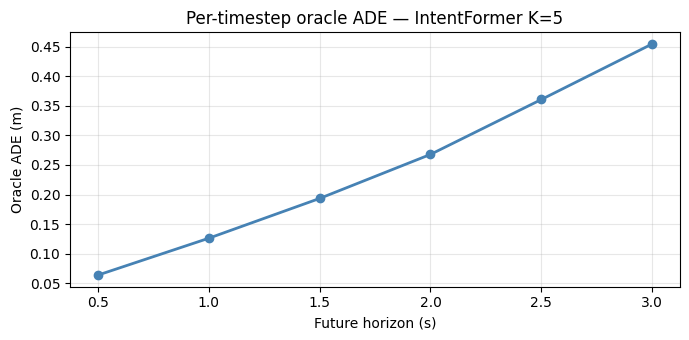

In [10]:
# ── Cell 8: Temporal ADE curve ────────────────────────────────────────────────
mu_r_test  = denorm(torch.tensor(test_res["mu"]),     std_x, std_y).numpy()
fut_r_test = denorm(torch.tensor(test_res["future"]), std_x, std_y).numpy()
per_mode   = np.linalg.norm(mu_r_test - fut_r_test[:,None,:,:], axis=-1)
oracle_k   = per_mode.mean(-1).argmin(axis=1)
oracle_t   = mu_r_test[np.arange(len(oracle_k)), oracle_k]
per_step   = np.linalg.norm(oracle_t - fut_r_test, axis=-1)
t_vals     = [(t+1)*DT for t in range(FUTURE_LEN)]

for t, tv in enumerate(t_vals):
    print(f"  t={tv:.1f}s  {per_step[:,t].mean():.4f} m")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(t_vals, per_step.mean(axis=0), "o-", color="steelblue", lw=2, ms=6)
ax.set_xlabel("Future horizon (s)"); ax.set_ylabel("Oracle ADE (m)")
ax.set_title(f"Per-timestep oracle ADE — IntentFormer K={K}")
ax.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/temporal_ade_curve.png", dpi=150, bbox_inches="tight")
plt.show()


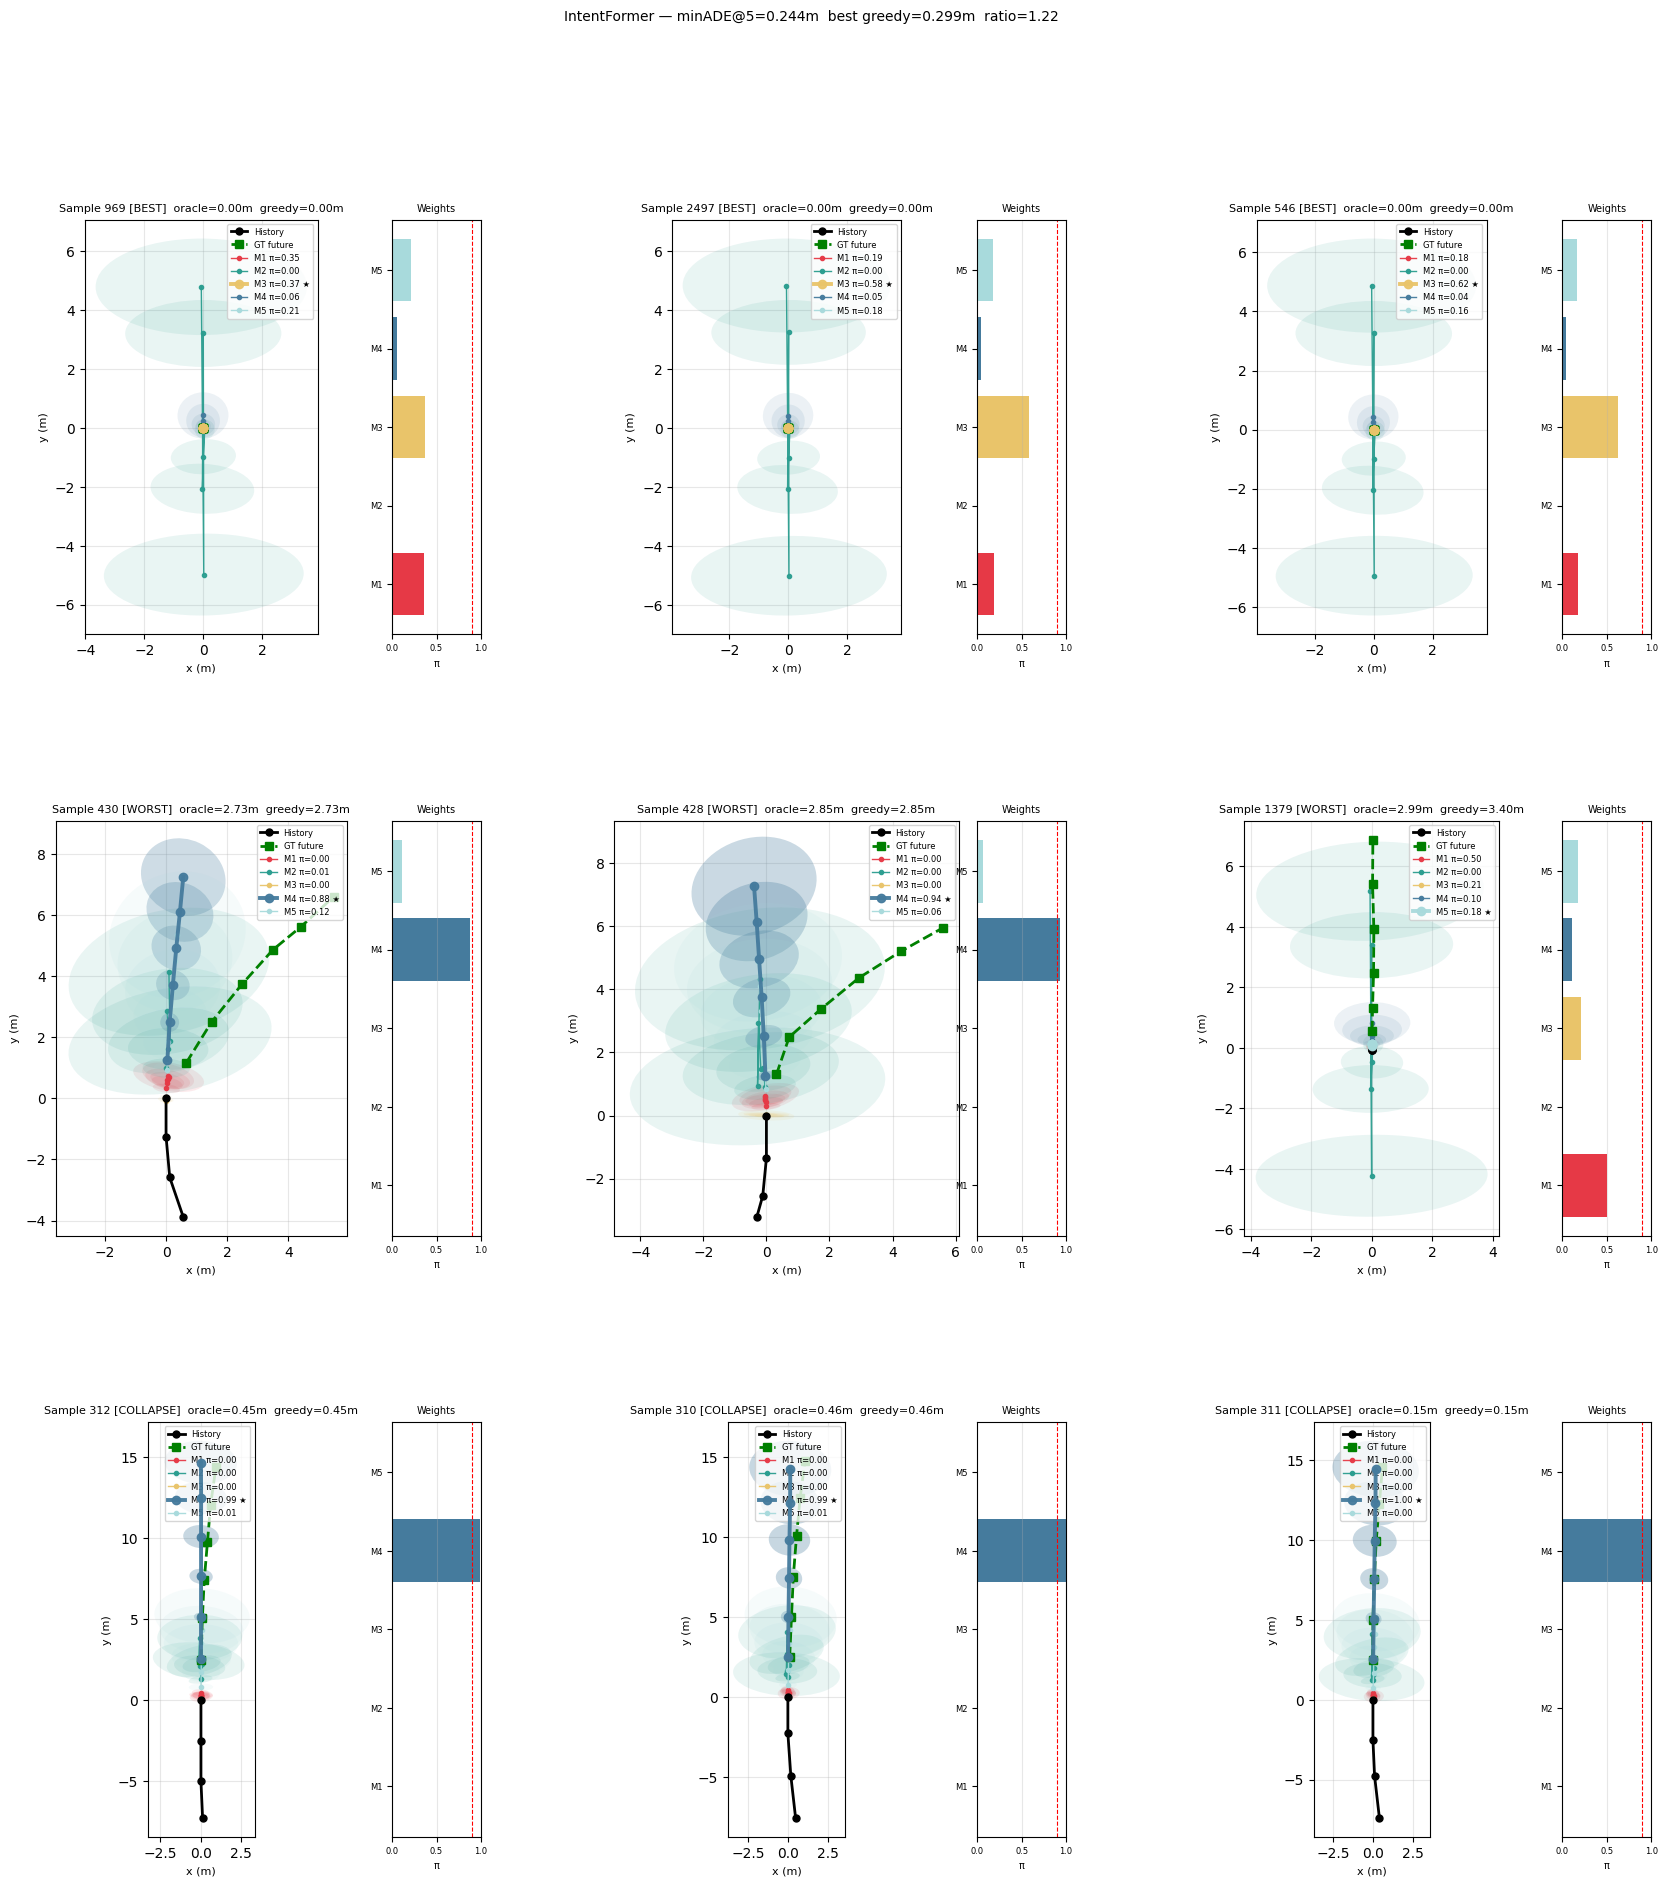

✓ Saved trajectory_predictions.png


In [11]:
# ── Cell 9: Trajectory visualisation ─────────────────────────────────────────
MCOLS = ["#E63946","#2A9D8F","#E9C46A","#457B9D","#A8DADC"]
sorted_err   = np.argsort(oracle_m)
best_idx     = sorted_err[:3].tolist()
worst_idx    = sorted_err[-3:].tolist()
collapse_idx = np.argsort(test_res["pi_arr"].max(axis=1))[-3:].tolist()
seen = set(); display_indices = []
for idx in best_idx + worst_idx + collapse_idx:
    if idx not in seen: display_indices.append(idx); seen.add(idx)

ncols = 3; nrows = math.ceil(len(display_indices)/ncols)
fig   = plt.figure(figsize=(21, nrows*7))
gs_out = fig.add_gridspec(nrows, ncols, hspace=0.45, wspace=0.28)
def dn(xy): return np.stack([xy[...,0]*std_x, xy[...,1]*std_y], axis=-1)

for pi_, idx in enumerate(display_indices):
    row, col = divmod(pi_, ncols)
    gs_in = gs_out[row,col].subgridspec(1, 2, width_ratios=[4,1], wspace=0.06)
    ax = fig.add_subplot(gs_in[0]); ax_pi = fig.add_subplot(gs_in[1])
    past_m = dn(test_res["past"][idx,:,:2]); gt_m = dn(test_res["future"][idx])
    mu_m   = dn(test_res["mu"][idx]); sig_m = np.stack([test_res["sigma"][idx,...,0]*std_x,
                                                         test_res["sigma"][idx,...,1]*std_y], axis=-1)
    rho_np = test_res["rho"][idx]; pi_np = test_res["pi_arr"][idx]
    vel = test_res["past"][idx,-1,:2] - test_res["past"][idx,-2,:2]
    sel_k = int(np.linalg.norm(mu_m[:,-1,:] - dn(test_res["past"][idx,-1,:2]+vel*FUTURE_LEN), axis=-1).argmin())
    ax.plot(past_m[:,0], past_m[:,1], "ko-", lw=2, ms=5, zorder=5, label="History")
    ax.plot(gt_m[:,0],   gt_m[:,1],   "gs--", lw=2, ms=6, zorder=5, label="GT future")
    for k in range(K):
        c = MCOLS[k]; lw = 2.8 if k==sel_k else 1.0
        lbl = f"M{k+1} π={pi_np[k]:.2f}" + (" ★" if k==sel_k else "")
        ax.plot(mu_m[k,:,0], mu_m[k,:,1], "o-", color=c, lw=lw,
                ms=6 if k==sel_k else 3, alpha=0.95, zorder=6 if k==sel_k else 4, label=lbl)
        for t in range(FUTURE_LEN):
            sx = max(float(sig_m[k,t,0]), 0.05); sy = max(float(sig_m[k,t,1]), 0.05)
            rho = float(rho_np[k,t])
            ang = 0.5*np.degrees(np.arctan2(2*rho*sx*sy, sx**2-sy**2+1e-9))
            ax.add_patch(Ellipse(xy=(mu_m[k,t,0],mu_m[k,t,1]), width=2*sx, height=2*sy,
                                 angle=ang, color=c, alpha=max(0.1,0.3*float(pi_np[k])),
                                 zorder=2, linewidth=0))
    bucket = "BEST" if idx in best_idx else ("WORST" if idx in worst_idx else "COLLAPSE")
    ax.set_title(f"Sample {idx} [{bucket}]  oracle={oracle_m[idx]:.2f}m  greedy={best_arr[idx]:.2f}m",
                 fontsize=8); ax.set_xlabel("x (m)", fontsize=8); ax.set_ylabel("y (m)", fontsize=8)
    ax.legend(fontsize=6, loc="upper right"); ax.grid(True, alpha=0.3); ax.set_aspect("equal")
    ax_pi.barh([f"M{k+1}" for k in range(K)], pi_np, color=MCOLS)
    ax_pi.axvline(0.9, color="red", ls="--", lw=0.8)
    ax_pi.set_xlim(0,1); ax_pi.set_xlabel("π", fontsize=7); ax_pi.set_title("Weights", fontsize=7)
    ax_pi.tick_params(labelsize=6); ax_pi.grid(True, alpha=0.3, axis="x")

fig.suptitle(f"IntentFormer — minADE@{K}={oracle_m.mean():.3f}m  "
             f"best greedy={best_arr.mean():.3f}m  ratio={best_arr.mean()/oracle_m.mean():.2f}",
             fontsize=10)
plt.savefig(f"{OUTPUT_DIR}/trajectory_predictions.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ Saved trajectory_predictions.png")


Mode collapse (max_pi>0.9): 0.4%


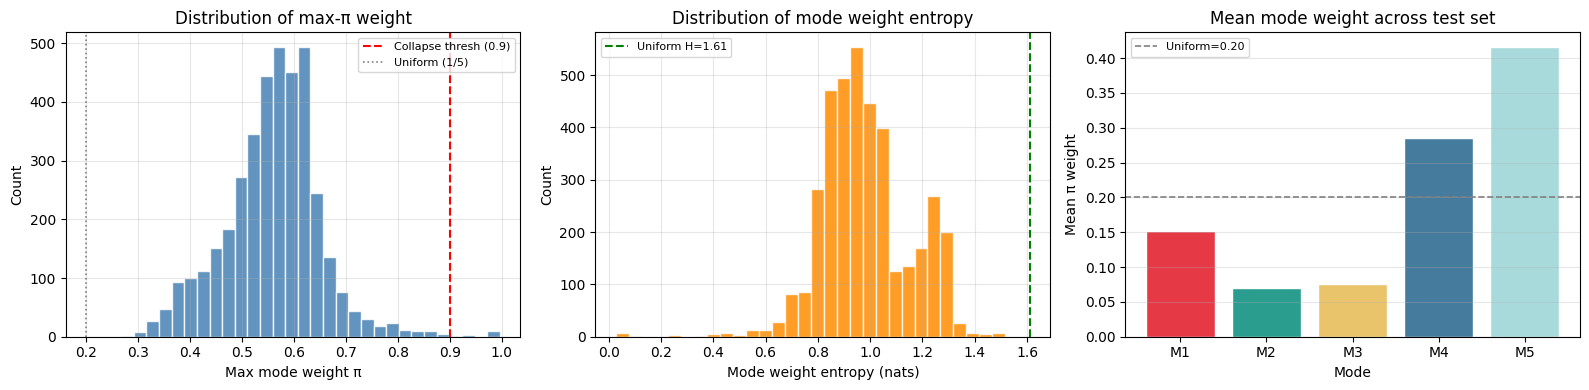

In [12]:
# ── Cell 10: Mode weight distribution ────────────────────────────────────────
pi_arr = test_res["pi_arr"]; max_pi = pi_arr.max(axis=1)
entropy = -(pi_arr * np.log(pi_arr.clip(1e-9))).sum(axis=1); uniform_H = math.log(K)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(max_pi, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(0.9, color="red",  ls="--", lw=1.5, label="Collapse thresh (0.9)")
axes[0].axvline(1/K, color="gray", ls=":",  lw=1.2, label=f"Uniform (1/{K})")
axes[0].set_xlabel("Max mode weight π"); axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of max-π weight"); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].hist(entropy, bins=30, color="darkorange", edgecolor="white", alpha=0.85)
axes[1].axvline(uniform_H, color="green", ls="--", lw=1.5, label=f"Uniform H={uniform_H:.2f}")
axes[1].set_xlabel("Mode weight entropy (nats)"); axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of mode weight entropy"); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
mean_pi = pi_arr.mean(axis=0)
axes[2].bar([f"M{k+1}" for k in range(K)], mean_pi, color=MCOLS, edgecolor="white")
axes[2].axhline(1/K, color="gray", ls="--", lw=1.2, label=f"Uniform={1/K:.2f}")
axes[2].set_xlabel("Mode"); axes[2].set_ylabel("Mean π weight")
axes[2].set_title("Mean mode weight across test set"); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3, axis="y")
print(f"Mode collapse (max_pi>0.9): {(max_pi>0.9).mean()*100:.1f}%")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/mode_weight_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
